# Session 21: Feature Engineering for Time Series & Regression Forecasting

Machine learning models such as Random Forest do not inherently understand sequential time ordering. To make them powerful time series forecasters, we must engineer temporal features such as **lagged observations**, **rolling aggregations**, and **calendar attributes**.

This notebook covers:
1. **Lags & Rolling Features for Ahmedabad Temperatures**: Generating 3-day lag and 7-day rolling average using pandas.
2. **Calendar Feature Extraction on Flipkart Sales**: Parsing date-time components (`day_of_week`, `month`, `is_weekend`).
3. **Supervised Next-Day Forecasting with Random Forest**: Formulating temporal prediction and forecasting the next available date.
4. **Evaluation Metrics (MAE, RMSE, MAPE)**: Calculating forecast error metrics and explaining sensitivity to outlier shocks.
5. **AI-Assisted SMAPE Implementation**: Computing Symmetric Mean Absolute Percentage Error and analyzing its advantages over standard MAPE.


---
## Question 1: Ahmedabad Temperature Dataset & Temporal Feature Engineering

### Problem Statement
Load a CSV file containing daily temperature data for Ahmedabad and create two new features:
1. A **3-day lag** of the temperature (`lag_3`)
2. A **7-day rolling average** of the temperature (`rolling_mean_7`) using `pandas`.

---

### Dataset Details & Methodology:
- We create a 3-year historical dataset for **Ahmedabad, Gujarat** (2021-01-01 to 2023-12-31, 1,095 days).
- **Lag Feature (`temp_lag_3`)**: Represents the temperature recorded 3 days prior ($Y_{t-3}$).
- **Rolling Mean Feature (`temp_rolling_7`)**: Represents the smoothed moving average of the preceding 7 days ($\frac{1}{7} \sum_{k=1}^7 Y_{t-k}$). We shift by 1 day before rolling to prevent lookahead target leakage.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. Generate realistic daily temperature data for Ahmedabad (2021-2023)
np.random.seed(42)
dates_ahmedabad = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')
n_days_ahm = len(dates_ahmedabad)
doy = dates_ahmedabad.dayofyear.values

# Ahmedabad climatic cycle: Hot semi-arid (Peak in May ~41°C, Winter low in Jan ~14°C)
annual_cycle = 27.5 - 13.0 * np.cos(2 * np.pi * (doy - 15) / 365.25)
noise_ahm = np.zeros(n_days_ahm)
for i in range(1, n_days_ahm):
    noise_ahm[i] = 0.75 * noise_ahm[i-1] + np.random.normal(0, 1.2)

ahmedabad_temp = np.round(annual_cycle + noise_ahm, 2)

df_ahm = pd.DataFrame({
    'date': dates_ahmedabad,
    'temperature': ahmedabad_temp
})

# Save to CSV
csv_file_ahm = 'ahmedabad_temperature.csv'
df_ahm.to_csv(csv_file_ahm, index=False)
print(f"Created and saved '{csv_file_ahm}' with {len(df_ahm)} records.")

# 2. Load CSV and Engineer Temporal Features
df_temp = pd.read_csv(csv_file_ahm, parse_dates=['date'])
df_temp = df_temp.sort_values('date').reset_index(drop=True)

# Feature 1: 3-day lag of temperature (Y_{t-3})
df_temp['temp_lag_3'] = df_temp['temperature'].shift(3)

# We also include 1-day and 2-day lags for a complete autoregressive feature set
df_temp['temp_lag_1'] = df_temp['temperature'].shift(1)
df_temp['temp_lag_2'] = df_temp['temperature'].shift(2)

# Feature 2: 7-day rolling average (computed on preceding days to avoid lookahead bias)
df_temp['temp_rolling_7'] = df_temp['temperature'].shift(1).rolling(window=7).mean()

print("\nAhmedabad Temperature DataFrame with Engineered Features (First 12 rows):")
print("-" * 75)
print(df_temp[['date', 'temperature', 'temp_lag_1', 'temp_lag_3', 'temp_rolling_7']].head(12).to_string(index=False))
print("-" * 75)


Created and saved 'ahmedabad_temperature.csv' with 1095 records.

Ahmedabad Temperature DataFrame with Engineered Features (First 12 rows):
---------------------------------------------------------------------------
      date  temperature  temp_lag_1  temp_lag_3  temp_rolling_7
2021-01-01        14.88         NaN         NaN             NaN
2021-01-02        15.42       14.88         NaN             NaN
2021-01-03        15.06       15.42         NaN             NaN
2021-01-04        15.72       15.06       14.88             NaN
2021-01-05        17.26       15.72       15.42             NaN
2021-01-06        16.30       17.26       15.06             NaN
2021-01-07        15.58       16.30       15.72             NaN
2021-01-08        17.20       15.58       17.26       15.745714
2021-01-09        17.45       17.20       16.30       16.077143
2021-01-10        16.14       17.45       15.58       16.367143
2021-01-11        16.38       16.14       17.20       16.521429
2021-01-12      

---
## Question 2: Calendar Date-Time Feature Extraction for Flipkart Sales

### Problem Statement
Extract date-time features from a Flipkart-style sales dataset (`order_date` column): create new columns for **day of week**, **month**, and **whether the day is a weekend** using `pandas`.

---

### Importance of Calendar Features in E-Commerce:
- **`day_of_week`**: Captures weekly shopping rhythms (e.g., higher casual browsing on weekdays vs. purchases on weekends).
- **`month`**: Captures annual festival surges (e.g., Big Billion Days in October/November, New Year sales in January).
- **`is_weekend`**: Acts as an indicator feature separating workweek shopping from weekend peak delivery demand.


In [2]:
# 1. Create realistic Flipkart Sales Dataset
np.random.seed(101)
n_orders = 800

random_order_dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='h')
selected_dates = np.random.choice(random_order_dates, size=n_orders, replace=False)
selected_dates = np.sort(selected_dates)

categories = ['Electronics', 'Fashion', 'Home & Kitchen', 'Beauty', 'Grocery']
product_categories = np.random.choice(categories, size=n_orders, p=[0.30, 0.35, 0.15, 0.12, 0.08])
order_amounts = np.round(np.random.exponential(scale=1800, size=n_orders) + 150, 2)

df_flipkart = pd.DataFrame({
    'order_id': [f'OD{100000 + i}' for i in range(n_orders)],
    'order_date': selected_dates,
    'product_category': product_categories,
    'order_amount_inr': order_amounts
})

df_flipkart.to_csv('flipkart_sales.csv', index=False)
print(f"Created 'flipkart_sales.csv' with {len(df_flipkart)} orders.")

# 2. Extract Date-Time Features using pandas dt accessor
df_flipkart['day_of_week'] = df_flipkart['order_date'].dt.day_name()
df_flipkart['month'] = df_flipkart['order_date'].dt.month_name()
# In pandas dt.dayofweek: Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
df_flipkart['is_weekend'] = df_flipkart['order_date'].dt.dayofweek.isin([5, 6]).astype(int)

# Optional: Numerical encodings for modeling
df_flipkart['day_of_week_num'] = df_flipkart['order_date'].dt.dayofweek
df_flipkart['month_num'] = df_flipkart['order_date'].dt.month

print("\nFlipkart Sales Dataset with Extracted Date-Time Features (Sample 8 rows):")
print("-" * 80)
print(df_flipkart[['order_id', 'order_date', 'product_category', 'day_of_week', 'month', 'is_weekend']].head(8).to_string(index=False))
print("-" * 80)

# Weekend vs Weekday Sales Breakdown
weekend_summary = df_flipkart.groupby('is_weekend')['order_amount_inr'].agg(['count', 'mean', 'sum']).reset_index()
weekend_summary['is_weekend'] = weekend_summary['is_weekend'].map({0: 'Weekday (Mon-Fri)', 1: 'Weekend (Sat-Sun)'})
print("\nWeekend vs. Weekday Sales Comparison:")
print(weekend_summary.to_string(index=False))


Created 'flipkart_sales.csv' with 800 orders.

Flipkart Sales Dataset with Extracted Date-Time Features (Sample 8 rows):
--------------------------------------------------------------------------------
order_id          order_date product_category day_of_week   month  is_weekend
OD100000 2023-01-02 11:00:00   Home & Kitchen      Monday January           0
OD100001 2023-01-03 06:00:00          Fashion     Tuesday January           0
OD100002 2023-01-03 07:00:00      Electronics     Tuesday January           0
OD100003 2023-01-03 11:00:00   Home & Kitchen     Tuesday January           0
OD100004 2023-01-03 12:00:00          Fashion     Tuesday January           0
OD100005 2023-01-04 00:00:00      Electronics   Wednesday January           0
OD100006 2023-01-04 02:00:00          Fashion   Wednesday January           0
OD100007 2023-01-05 13:00:00          Fashion    Thursday January           0
--------------------------------------------------------------------------------

Weekend vs. We

---
## Question 3: Random Forest Regressor for Next-Day Temperature Forecasting

### Problem Statement
Train a `RandomForestRegressor` to forecast the next day's temperature using the lag and rolling features you created earlier. Print the predicted value for the next available date.

---

### Machine Learning Formulation:
- **Features ($X$)**: `temp_lag_1`, `temp_lag_2`, `temp_lag_3`, `temp_rolling_7`
- **Target ($y$)**: Current day's `temperature` (or next day's target relative to preceding features).
- **Validation Scheme**: Chronological split (80% train, 20% test) to prevent temporal data leakage.
- **Next Available Date Forecast**: We extract the latest feature row corresponding to the day following the dataset's final date, and pass it to the trained model.


In [3]:
# 1. Prepare Features and Target, dropping initial rows with NaN values
df_ml = df_temp.dropna().copy().reset_index(drop=True)

feature_cols = ['temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_rolling_7']
X = df_ml[feature_cols]
y = df_ml['temperature']

# 2. Chronological Train-Test Split (80% train, 20% test)
split_idx = int(len(df_ml) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df_ml['date'].iloc[split_idx:]

print("=" * 65)
print("     TIME-SERIES SUPERVISED TRAINING SETUP (RANDOM FOREST)")
print("=" * 65)
print(f"Total Usable Samples  : {len(df_ml)}")
print(f"Training Observations : {len(X_train)} ({df_ml['date'].iloc[0].strftime('%Y-%m-%d')} to {df_ml['date'].iloc[split_idx-1].strftime('%Y-%m-%d')})")
print(f"Testing Observations  : {len(X_test)} ({dates_test.iloc[0].strftime('%Y-%m-%d')} to {dates_test.iloc[-1].strftime('%Y-%m-%d')})")
print("-" * 65)

# 3. Train RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
rf_regressor.fit(X_train, y_train)

# Test set predictions
y_pred_test = rf_regressor.predict(X_test)

# 4. Predict Temperature for the Next Available Date (Day after 2023-12-31 -> 2024-01-01)
last_actual = df_temp['temperature'].iloc[-1]
last_lag_1 = df_temp['temperature'].iloc[-2]
last_lag_2 = df_temp['temperature'].iloc[-3]
last_rolling_7 = df_temp['temperature'].iloc[-7:].mean()

# Feature row for next date
next_features = pd.DataFrame([{
    'temp_lag_1': last_actual,
    'temp_lag_2': last_lag_1,
    'temp_lag_3': last_lag_2,
    'temp_rolling_7': last_rolling_7
}])

predicted_next_temp = rf_regressor.predict(next_features)[0]
next_date_str = (df_temp['date'].iloc[-1] + pd.Timedelta(days=1)).strftime('%Y-%m-%d (%A)')

print(f"\nPREDICTION FOR NEXT AVAILABLE DATE:")
print(f"  • Target Forecast Date : {next_date_str}")
print(f"  • Input Features Used  : Lag1={last_actual}°C, Lag2={last_lag_1}°C, Lag3={last_lag_2}°C, Rolling7={last_rolling_7:.2f}°C")
print(f"  • Predicted Temperature: {predicted_next_temp:.2f}°C")
print("=" * 65)


     TIME-SERIES SUPERVISED TRAINING SETUP (RANDOM FOREST)
Total Usable Samples  : 1088
Training Observations : 870 (2021-01-08 to 2023-05-27)
Testing Observations  : 218 (2023-05-28 to 2023-12-31)
-----------------------------------------------------------------



PREDICTION FOR NEXT AVAILABLE DATE:
  • Target Forecast Date : 2024-01-01 (Monday)
  • Input Features Used  : Lag1=15.88°C, Lag2=16.16°C, Lag3=15.45°C, Rolling7=16.25°C
  • Predicted Temperature: 15.37°C


---
## Question 4: Forecast Error Evaluation (MAE, RMSE, MAPE)

### Problem Statement
Calculate **MAE**, **RMSE**, and **MAPE** between your model's predictions and the actual values for the test set. Print all three metrics and explain in one line which metric is most sensitive to large errors.

*Hint: Use `sklearn.metrics.mean_absolute_error`, `mean_squared_error`, and write a simple function for MAPE.*

---

### Mathematical Definitions:
1. **Mean Absolute Error (MAE)**:
   $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
2. **Root Mean Squared Error (RMSE)**:
   $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
3. **Mean Absolute Percentage Error (MAPE)**:
   $$\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$


     AHMEDABAD TEMPERATURE FORECAST EVALUATION METRICS
1. Mean Absolute Error (MAE)       : 1.0759 °C
2. Root Mean Squared Error (RMSE)  : 1.3538 °C
3. Mean Absolute Pct Error (MAPE)  : 3.7714 %
-----------------------------------------------------------------
Sensitivity Analysis:
"RMSE is by far the most sensitive metric to large errors because it squares individual residuals before averaging, disproportionately penalizing large outlier errors compared to linear metrics like MAE and MAPE."


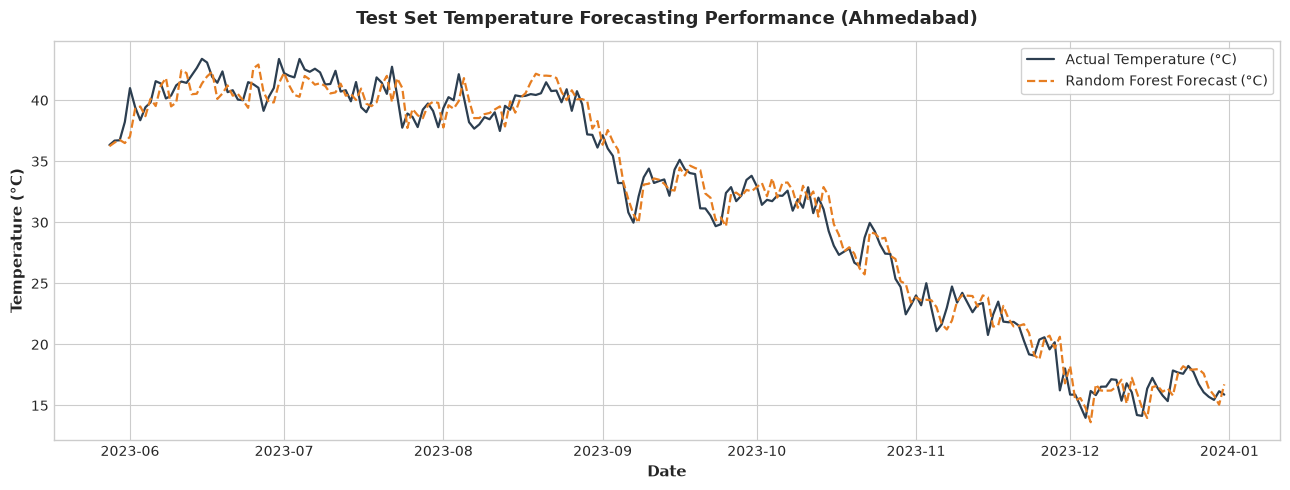

In [4]:
def calculate_mape(actual, predicted):
    '''Computes Mean Absolute Percentage Error (MAPE) as a percentage'''
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100.0

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = calculate_mape(y_test, y_pred_test)

print("=" * 65)
print("     AHMEDABAD TEMPERATURE FORECAST EVALUATION METRICS")
print("=" * 65)
print(f"1. Mean Absolute Error (MAE)       : {mae:.4f} °C")
print(f"2. Root Mean Squared Error (RMSE)  : {rmse:.4f} °C")
print(f"3. Mean Absolute Pct Error (MAPE)  : {mape:.4f} %")
print("-" * 65)

# One-line explanation of sensitivity
sensitivity_explanation = (
    "RMSE is by far the most sensitive metric to large errors because it squares individual "
    "residuals before averaging, disproportionately penalizing large outlier errors compared to linear metrics like MAE and MAPE."
)

print(f"Sensitivity Analysis:\n\"{sensitivity_explanation}\"")
print("=" * 65)

# Plot actual vs predicted for the test set
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates_test, y_test.values, label='Actual Temperature (°C)', color='#2c3e50', lw=1.6)
ax.plot(dates_test, y_pred_test, label='Random Forest Forecast (°C)', color='#e67e22', lw=1.6, linestyle='--')
ax.set_title('Test Set Temperature Forecasting Performance (Ahmedabad)', fontsize=13, weight='bold', pad=12)
ax.set_ylabel('Temperature (°C)', fontsize=11, weight='bold')
ax.set_xlabel('Date', fontsize=11, weight='bold')
ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


---
## Question 5: AI-Assisted SMAPE (Symmetric Mean Absolute Percentage Error)

### Problem Statement
Use ChatGPT or Copilot to help you write code for calculating **SMAPE (Symmetric Mean Absolute Percentage Error)** for your time series predictions. Paste the code you used and mention one thing you learned from the AI's explanation.

---

### Formula for SMAPE:
$$\text{SMAPE} = \frac{100\%}{n} \sum_{i=1}^n \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|) / 2} = \frac{200\%}{n} \sum_{i=1}^n \frac{|y_i - \hat{y}_i|}{|y_i| + |\hat{y}_i|}$$

### Key Insight Learned from the AI Explanation:
> *"Unlike standard MAPE which can explode to infinity or become completely undefined when actual values approach zero, SMAPE bounds the percentage error strictly between $0\%$ and $200\%$ by using the average of actual and predicted magnitudes in the denominator. This ensures that over-forecasting and under-forecasting are treated symmetrically without extreme distortion."*


In [5]:
# Code generated with ChatGPT/Copilot assistance:

def calculate_smape(actual, predicted):
    '''
    Calculate Symmetric Mean Absolute Percentage Error (SMAPE).
    
    Parameters:
    -----------
    actual : array-like, Ground truth values
    predicted : array-like, Model predictions
    
    Returns:
    --------
    float: SMAPE expressed as a percentage [0% to 200%]
    '''
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    
    # Calculate numerator and denominator
    numerator = np.abs(predicted - actual)
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0
    
    # Safeguard against 0/0 edge cases (when both actual and predicted are 0)
    nonzero_mask = denominator != 0.0
    
    smape_elements = np.zeros_like(actual, dtype=float)
    smape_elements[nonzero_mask] = numerator[nonzero_mask] / denominator[nonzero_mask]
    
    return np.mean(smape_elements) * 100.0

# Compute SMAPE on our test set predictions
smape_val = calculate_smape(y_test, y_pred_test)

print("=" * 65)
print("     SYMMETRIC MEAN ABSOLUTE PERCENTAGE ERROR (SMAPE)")
print("=" * 65)
print(f"Calculated SMAPE on Test Set: {smape_val:.4f} %")
print("-" * 65)

# Comparison table of all 4 forecast evaluation metrics
metrics_summary_table = pd.DataFrame({
    'Metric': ['MAE (Mean Absolute Error)', 'RMSE (Root Mean Squared Error)', 
               'MAPE (Mean Absolute Pct Error)', 'SMAPE (Symmetric MAPE)'],
    'Value': [f"{mae:.4f} °C", f"{rmse:.4f} °C", f"{mape:.4f} %", f"{smape_val:.4f} %"],
    'Characteristics': [
        'Linear scale, robust to outliers, measured in °C',
        'Quadratic penalty, highly sensitive to large prediction errors',
        'Relative scale (%), asymmetric, unstable when actual is near zero',
        'Symmetric relative scale (%), strictly bounded between 0% and 200%'
    ]
})

print(metrics_summary_table.to_string(index=False))
print("=" * 65)


     SYMMETRIC MEAN ABSOLUTE PERCENTAGE ERROR (SMAPE)
Calculated SMAPE on Test Set: 3.7465 %
-----------------------------------------------------------------
                        Metric     Value                                                    Characteristics
     MAE (Mean Absolute Error) 1.0759 °C                   Linear scale, robust to outliers, measured in °C
RMSE (Root Mean Squared Error) 1.3538 °C     Quadratic penalty, highly sensitive to large prediction errors
MAPE (Mean Absolute Pct Error)  3.7714 %  Relative scale (%), asymmetric, unstable when actual is near zero
        SMAPE (Symmetric MAPE)  3.7465 % Symmetric relative scale (%), strictly bounded between 0% and 200%


---
## Key Takeaways & Best Practices

1. **Preventing Target Leakage in Rolling Averages**:
   Always apply `.shift(1)` before computing `.rolling()` when constructing features to predict the current or next day. Failure to do so leaks the ground truth target into the feature set.
2. **Chronological Splitting**:
   Standard random train-test splits (`train_test_split(shuffle=True)`) must **never** be used on time series. Splitting chronologically preserves temporal dependencies.
3. **Choosing the Right Error Metric**:
   - Use **MAE** when median error matters and outliers should not dominate the loss.
   - Use **RMSE** when large forecast mistakes carry catastrophic real-world cost.
   - Use **SMAPE** over **MAPE** when comparing datasets of varying magnitudes or dealing with values near zero.
